# 🏃 RAdam, Lookahead, and Ranger — Variance Rectification and Fast/Slow Weight Averaging

This notebook covers three related, complementary ideas from the 2019 optimizer literature:

- **RAdam** (Rectified Adam) — fixes Adam's undesirably large *variance* in the adaptive learning rate during
  the early stage of training by explicitly tracking the reliability of the second-moment estimate and
  falling back to plain SGD-with-momentum when that estimate is not yet trustworthy.
- **Lookahead** — a generic wrapper around *any* base optimizer that maintains a pair of weights
  (fast θ, slow φ), takes several fast exploratory steps, then interpolates the slow weights towards the
  fast ones. This reduces the variance of the final update without extra hyperparameter tuning of the base
  optimizer.
- **Ranger** — simply RAdam wrapped inside Lookahead. It combines both ideas into a single optimizer that
  was popular in Kaggle / fast.ai circles around 2019–2020.

References:
- Liu et al. (2019), *On the Variance of the Adaptive Learning Rate and Beyond* — introduces **RAdam**.
- Zhang et al. (2019), *Lookahead Optimizer: k steps forward, 1 step back* — introduces **Lookahead**.
- Wright, L. (2019), *New Deep Learning Optimizer, Ranger* — the community combination of RAdam + Lookahead
  known as **Ranger**.

This notebook is pedagogical: the implementations below are simplified for clarity and visualization; they
are **not** production-ready optimizer classes for deep learning frameworks.

## 🔍 Conceptual Intuition

**Why does Adam need "rectifying"?** Adam's update divides the (bias-corrected) momentum $\hat m_t$ by the
square root of the (bias-corrected) second moment $\hat v_t$. Early in training, $\hat v_t$ is an average of
only a handful of squared gradients — a *high-variance* estimate of the true gradient scale. Dividing by a
noisy denominator amplifies that noise into the update itself, which is why Adam is often paired with an
ad-hoc learning-rate **warmup** in practice. RAdam replaces the ad-hoc warmup with a principled fix:

1. Track $\rho_t$, an analytic approximation of the *effective sample size* backing the second-moment
   estimate at step $t$:
$$
\rho_\infty = \frac{2}{1-\beta_2} - 1, \qquad
\rho_t = \rho_\infty - \frac{2 t \beta_2^{t}}{1-\beta_2^{t}}
$$
2. Once $\rho_t > 4$ (the variance of $\hat v_t$ is analytically tractable), scale the adaptive term by a
   rectification factor $r_t \in (0, 1]$ that grows from ~0 towards 1 as $\rho_t \to \rho_\infty$:
$$
r_t = \sqrt{\frac{(\rho_t-4)(\rho_t-2)\rho_\infty}{(\rho_\infty-4)(\rho_\infty-2)\rho_t}}
$$
3. Before $\rho_t > 4$, the adaptive denominator is deemed unreliable, so RAdam falls back to a plain
   **SGD-with-momentum** update (no adaptive denominator at all) using just $\hat m_t$.

**Why does Lookahead help?** Instead of tuning the base optimizer more carefully, Lookahead runs it for $k$
"fast" steps from the current slow weights $\phi$, producing exploratory fast weights $\theta$, and then only
commits a fraction $\alpha$ of the way there: $\phi \leftarrow \phi + \alpha(\theta - \phi)$. The fast weights
are then reset to the new slow weights. Intuitively this looks ahead along the fast trajectory before
committing, which damps oscillations and reduces the variance of the final update — for (almost) free,
since it wraps *any* base optimizer.

**Ranger** simply uses RAdam as the base optimizer inside a Lookahead wrapper, combining reduced early-stage
variance (RAdam) with reduced step-to-step variance from exploratory averaging (Lookahead).

We will:
1. Implement all three optimizers from scratch in NumPy.
2. Compare trajectories and loss curves on a shared non-convex 2D test surface.
3. Directly verify RAdam's core motivating claim — lower variance of early-training loss across random
   seeds — with a dedicated controlled experiment.

### Step-1: Imports and Environment Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown

np.random.seed(42)

### Step-2: Defining Test Surface and its Gradient

In [2]:
# Non-convex test surface (Rosenbrock-like with ripples), same family used elsewhere in this repo
def f(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2 + 0.25 * np.sin(3.0 * x) * np.cos(2.5 * y)

def grad_f(x, y):
    # analytic gradient (derived for our chosen f)
    dfdx = -2*(1 - x) - 400*x*(y - x**2) + 0.75 * np.cos(3.0*x) * np.cos(2.5*y)
    dfdy = 200*(y - x**2) - 0.625 * np.sin(3.0*x) * np.sin(2.5*y)
    return np.array([dfdx, dfdy])

def clip_grad(g, max_norm=10.0):
    # Gradient clipping: near the corners of this surface |grad_f| can exceed 300, while
    # RAdam's SGD-momentum fallback phase (see Step-6) applies the *raw*, un-normalized
    # momentum as the update. Combined with a learning rate tuned for Adam-scale (~lr)
    # steps, an un-clipped raw gradient of that size blows the iterate up within a handful
    # of steps. Clipping is applied identically to every optimizer below for a fair comparison,
    # and mirrors standard practice (gradient clipping is routinely paired with adaptive/
    # momentum optimizers on badly-scaled problems).
    n = np.linalg.norm(g)
    if n > max_norm:
        g = g * (max_norm / n)
    return g

### Step-3: Mesh & Surface Prep

In [3]:
x_ax = np.linspace(-1.5, 1.8, 300)
y_ax = np.linspace(-0.5, 2.5, 300)
X, Y = np.meshgrid(x_ax, y_ax)
Z = f(X, Y)

### Step-4: Visualize the Test Surface

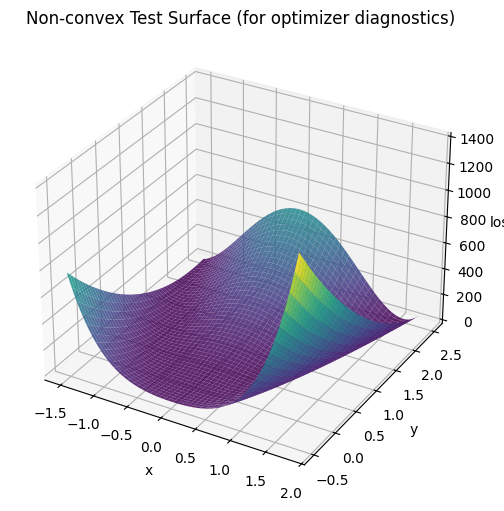

In [4]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha=0.85, linewidth=0, antialiased=True)
ax.set_title("Non-convex Test Surface (for optimizer diagnostics)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("loss")
plt.show()

### Step-5: Adam Baseline (Stateful Stepper)

In [5]:
class AdamStepper:
    """Plain Adam, one coordinate-wise step at a time. Kept as a small stateful object
    (rather than a function returning a whole path) so that Lookahead in Step-7 can wrap
    it — or any other stepper — without caring about its internals."""
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = np.zeros(2)
        self.v = np.zeros(2)
        self.t = 0

    def step(self, x, g):
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * g
        self.v = self.beta2 * self.v + (1 - self.beta2) * g * g
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        return x - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

### Step-6: RAdam Implementation

In [6]:
class RAdamStepper:
    """Rectified Adam (Liu et al. 2019). Identical moment bookkeeping to Adam, but the
    adaptive denominator is only trusted once rho_t > 4; before that we take a plain
    momentum-only (SGD-style) step using m_hat alone."""
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = np.zeros(2)
        self.v = np.zeros(2)
        self.t = 0
        self.rho_inf = 2.0 / (1 - beta2) - 1.0

    def step(self, x, g):
        self.t += 1
        t = self.t
        self.m = self.beta1 * self.m + (1 - self.beta1) * g
        self.v = self.beta2 * self.v + (1 - self.beta2) * g * g
        m_hat = self.m / (1 - self.beta1**t)

        rho_t = self.rho_inf - 2 * t * (self.beta2**t) / (1 - self.beta2**t)

        if rho_t > 4:
            # second-moment estimate is analytically tractable: use the rectified adaptive update
            v_hat = np.sqrt(self.v / (1 - self.beta2**t))
            r_t = np.sqrt(
                ((rho_t - 4) * (rho_t - 2) * self.rho_inf)
                / ((self.rho_inf - 4) * (self.rho_inf - 2) * rho_t)
            )
            return x - self.lr * r_t * m_hat / (v_hat + self.eps)
        else:
            # not enough effective samples yet -- fall back to SGD with momentum only
            return x - self.lr * m_hat


def run_optimizer(stepper_class, kwargs, grad_fn, start, n_iter=300, max_grad_norm=10.0):
    x = start.astype(float).copy()
    stepper = stepper_class(**kwargs)
    path = [x.copy()]
    for _ in range(n_iter):
        g = clip_grad(grad_fn(x[0], x[1]), max_grad_norm)
        x = stepper.step(x, g)
        path.append(x.copy())
    return np.array(path)

### Step-7: Lookahead Wrapper (Works with Any Base Stepper)

In [7]:
def run_lookahead(stepper_class, kwargs, grad_fn, start, k=5, alpha=0.5, n_iter=300, max_grad_norm=10.0):
    """Lookahead (Zhang et al. 2019): theta are 'fast' weights advanced by the base
    optimizer every step; phi are 'slow' weights that only move a fraction alpha of the
    way towards theta every k steps, at which point theta is reset to phi."""
    theta = start.astype(float).copy()
    phi = start.astype(float).copy()
    stepper = stepper_class(**kwargs)
    path = [phi.copy()]
    for t in range(n_iter):
        g = clip_grad(grad_fn(theta[0], theta[1]), max_grad_norm)
        theta = stepper.step(theta, g)
        if (t + 1) % k == 0:
            phi = phi + alpha * (theta - phi)
            theta = phi.copy()
        path.append(theta.copy())
    return np.array(path)

### Step-8: Ranger = RAdam Wrapped in Lookahead, and Running All Three

In [8]:
# Ranger is nothing more than: base optimizer = RAdam, wrapped by Lookahead.
start = np.array([0.9, 1.8])
n_iter = 300

path_adam   = run_optimizer(AdamStepper, dict(lr=0.01), grad_f, start, n_iter=n_iter)
path_radam  = run_optimizer(RAdamStepper, dict(lr=0.01), grad_f, start, n_iter=n_iter)
path_ranger = run_lookahead(RAdamStepper, dict(lr=0.01), grad_f, start, k=5, alpha=0.5, n_iter=n_iter)

loss_adam   = np.array([f(px, py) for px, py in path_adam])
loss_radam  = np.array([f(px, py) for px, py in path_radam])
loss_ranger = np.array([f(px, py) for px, py in path_ranger])

print(f"Adam   final: {path_adam[-1]},  loss={loss_adam[-1]:.4f}")
print(f"RAdam  final: {path_radam[-1]}, loss={loss_radam[-1]:.4f}")
print(f"Ranger final: {path_ranger[-1]}, loss={loss_ranger[-1]:.4f}")

Adam   final: [1.10849114 1.23021408],  loss=0.0576
RAdam  final: [1.25182101 1.56876261], loss=0.1661
Ranger final: [1.24059165 1.54077666], loss=0.1621


### Step-9: 2D Contour Trajectories

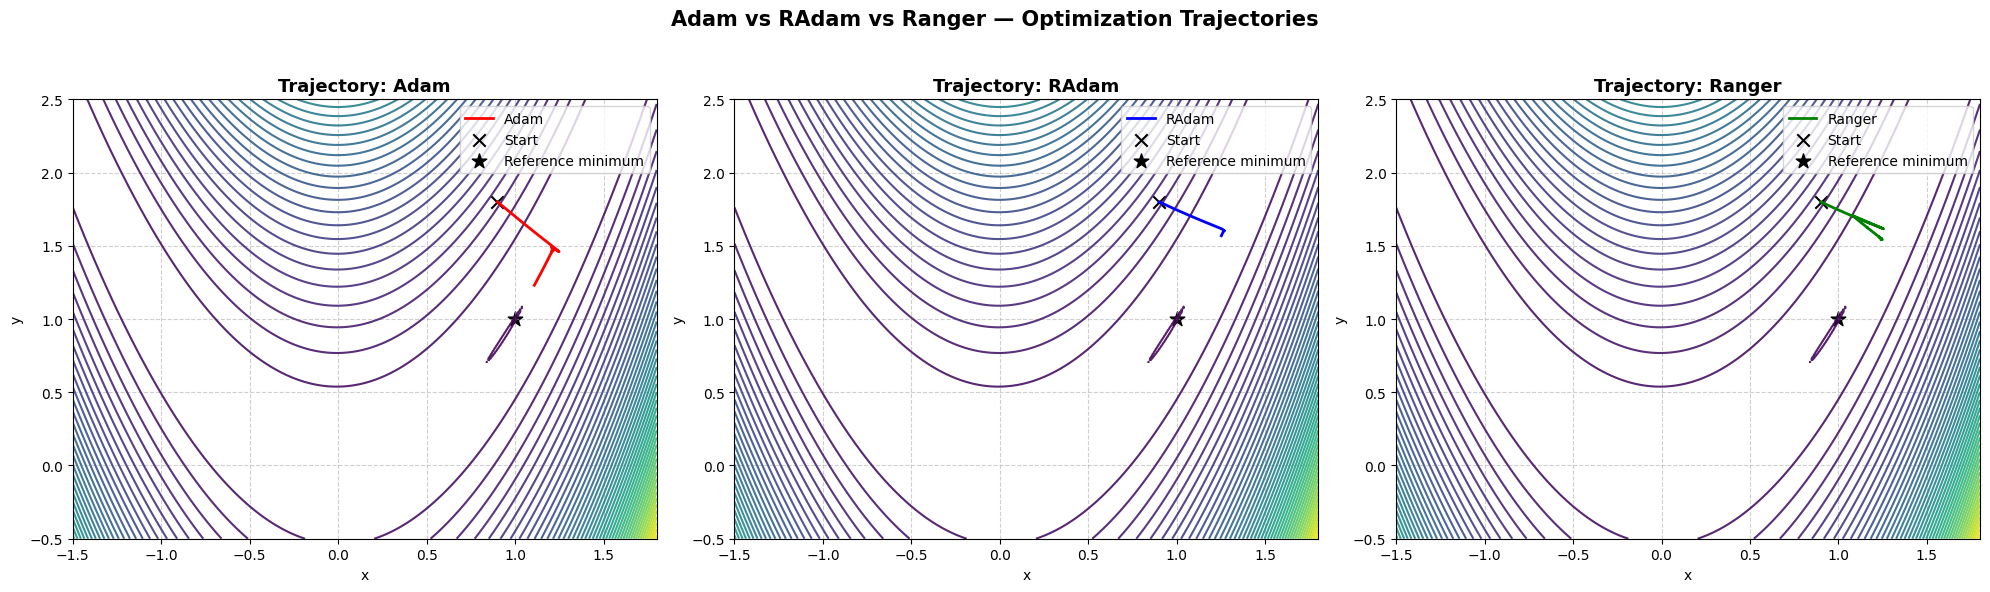

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, path, name, color in zip(
        axes, [path_adam, path_radam, path_ranger], ['Adam', 'RAdam', 'Ranger'], ['r', 'b', 'g']):
    ax.contour(X, Y, Z, levels=50, cmap='viridis', alpha=0.9)
    ax.plot(path[:, 0], path[:, 1], color=color, lw=2, label=name)
    ax.scatter(start[0], start[1], c='black', marker='x', s=80, label='Start')
    ax.scatter(1, 1, c='k', marker='*', s=120, label='Reference minimum')
    ax.set_title(f"Trajectory: {name}", fontsize=13, weight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
plt.suptitle("Adam vs RAdam vs Ranger — Optimization Trajectories", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Step-10: Loss vs Iteration (Log Scale)

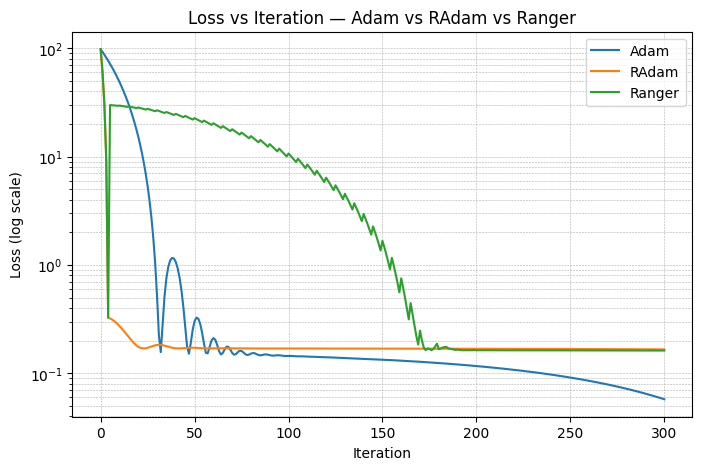

In [10]:
plt.figure(figsize=(8,5))
plt.plot(loss_adam, label='Adam')
plt.plot(loss_radam, label='RAdam')
plt.plot(loss_ranger, label='Ranger')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Loss (log scale)")
plt.title("Loss vs Iteration — Adam vs RAdam vs Ranger")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.4)
plt.show()

### Step-11: Visualizing the Rectification Term $r_t$

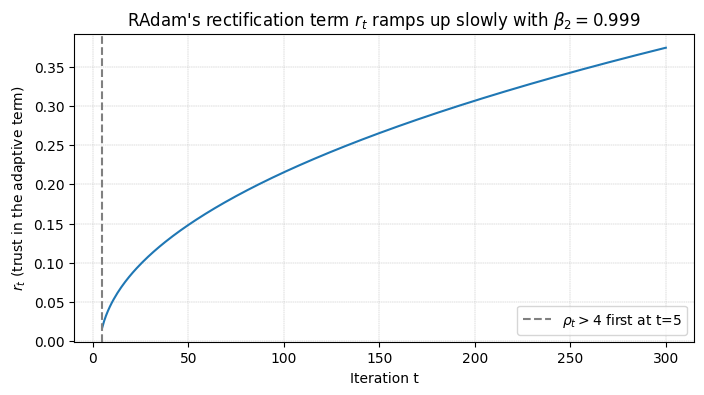

rho_t first exceeds 4 at iteration: 5


In [11]:
beta2 = 0.999
rho_inf = 2.0 / (1 - beta2) - 1.0
ts = np.arange(1, 301)
rho_ts = rho_inf - 2 * ts * (beta2**ts) / (1 - beta2**ts)
r_ts = np.full_like(rho_ts, np.nan)
mask = rho_ts > 4
r_ts[mask] = np.sqrt(
    ((rho_ts[mask] - 4) * (rho_ts[mask] - 2) * rho_inf) / ((rho_inf - 4) * (rho_inf - 2) * rho_ts[mask])
)

plt.figure(figsize=(8,4))
plt.plot(ts, r_ts)
plt.axvline(ts[mask][0], color='gray', ls='--', label=f'$\\rho_t>4$ first at t={ts[mask][0]}')
plt.xlabel("Iteration t")
plt.ylabel(r"$r_t$ (trust in the adaptive term)")
plt.title(r"RAdam's rectification term $r_t$ ramps up slowly with $\beta_2=0.999$")
plt.legend()
plt.grid(ls='--', lw=0.3)
plt.show()

print("rho_t first exceeds 4 at iteration:", int(ts[mask][0]))

### Step-12: Verifying RAdam's Core Claim — Lower Early-Training Variance

The motivating claim of the RAdam paper is *not* "RAdam converges faster" — it is that Adam's adaptive
learning rate has undesirably large **variance** early in training, which can derail optimization before
the second-moment estimate has stabilized. To isolate this effect cleanly (matching the spirit of the toy
illustration in the original paper) we start near the reference minimum, where the *systematic* gradient
from `grad_f` is small, and replace it with pure i.i.d. Gaussian gradient noise — mimicking the situation
where mini-batch noise dominates the true gradient signal (e.g. late in training, or on a low-curvature
plateau). We run many independent noise realizations ("seeds") and track the **variance of the loss across
seeds** at each iteration for Adam vs RAdam.

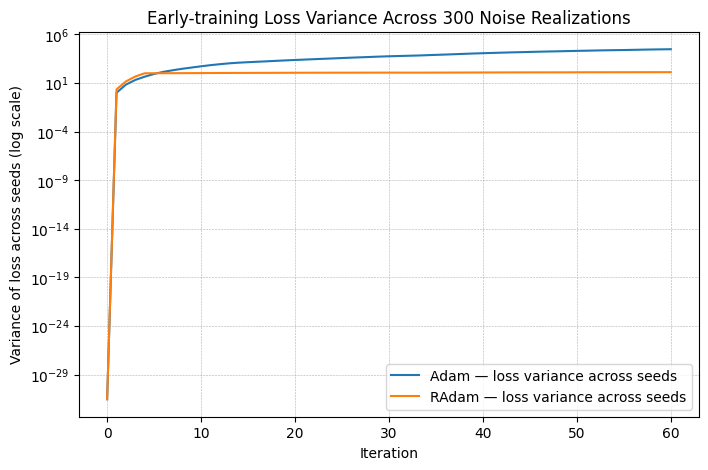

Mean variance, iterations 5-30: Adam=2010.84  RAdam=109.92


In [12]:
start_var = np.array([1.0, 1.0])
n_seeds = 300
n_iter_var = 60
noise_std = 1.0
lr_var = 0.05

losses_adam_seeds = np.zeros((n_seeds, n_iter_var + 1))
losses_radam_seeds = np.zeros((n_seeds, n_iter_var + 1))

for s in range(n_seeds):
    # same noise realization fed to both optimizers for an apples-to-apples comparison
    rng = np.random.default_rng(s)
    x = start_var.copy(); stepper = AdamStepper(lr=lr_var); path = [x.copy()]
    for _ in range(n_iter_var):
        g = rng.normal(0, noise_std, size=2)
        x = stepper.step(x, g)
        path.append(x.copy())
    losses_adam_seeds[s] = np.array([f(px, py) for px, py in path])

    rng = np.random.default_rng(s)
    x = start_var.copy(); stepper = RAdamStepper(lr=lr_var); path = [x.copy()]
    for _ in range(n_iter_var):
        g = rng.normal(0, noise_std, size=2)
        x = stepper.step(x, g)
        path.append(x.copy())
    losses_radam_seeds[s] = np.array([f(px, py) for px, py in path])

var_adam = losses_adam_seeds.var(axis=0)
var_radam = losses_radam_seeds.var(axis=0)

plt.figure(figsize=(8,5))
plt.plot(var_adam, label='Adam — loss variance across seeds')
plt.plot(var_radam, label='RAdam — loss variance across seeds')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Variance of loss across seeds (log scale)")
plt.title(f"Early-training Loss Variance Across {n_seeds} Noise Realizations")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.4)
plt.show()

print(f"Mean variance, iterations 5-30: Adam={var_adam[5:30].mean():.2f}  RAdam={var_radam[5:30].mean():.2f}")

### Step-13: Interactive Comparison

In [13]:
try:
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider
except ImportError:
    !pip install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact, FloatSlider, IntSlider

from IPython.display import clear_output

def interactive_compare(lr=0.01, beta2=0.999, k=5, alpha=0.5, n_iter=300):
    clear_output(wait=True)
    start = np.array([0.9, 1.8])

    p_adam   = run_optimizer(AdamStepper, dict(lr=lr, beta2=beta2), grad_f, start, n_iter=n_iter)
    p_radam  = run_optimizer(RAdamStepper, dict(lr=lr, beta2=beta2), grad_f, start, n_iter=n_iter)
    p_ranger = run_lookahead(RAdamStepper, dict(lr=lr, beta2=beta2), grad_f, start, k=k, alpha=alpha, n_iter=n_iter)

    l_adam   = np.array([f(px, py) for px, py in p_adam])
    l_radam  = np.array([f(px, py) for px, py in p_radam])
    l_ranger = np.array([f(px, py) for px, py in p_ranger])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].contour(X, Y, Z, levels=40, cmap='viridis')
    axes[0].plot(p_adam[:,0], p_adam[:,1], 'r-', label='Adam')
    axes[0].plot(p_radam[:,0], p_radam[:,1], 'b-', label='RAdam')
    axes[0].plot(p_ranger[:,0], p_ranger[:,1], 'g-', label='Ranger')
    axes[0].scatter(start[0], start[1], c='k', marker='x', s=80)
    axes[0].scatter(1, 1, c='k', marker='*', s=120)
    axes[0].set_title(f"Trajectories (lr={lr:.3f}, k={k}, alpha={alpha:.2f})")
    axes[0].legend()

    axes[1].plot(l_adam, 'r', label='Adam')
    axes[1].plot(l_radam, 'b', label='RAdam')
    axes[1].plot(l_ranger, 'g', label='Ranger')
    axes[1].set_yscale('log')
    axes[1].set_title("Loss vs Iteration (log)")
    axes[1].legend(); axes[1].grid(True, ls='--', lw=0.3)

    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"Final losses — Adam: **{l_adam[-1]:.4f}**, RAdam: **{l_radam[-1]:.4f}**, Ranger: **{l_ranger[-1]:.4f}**"
    ))

interact(
    interactive_compare,
    lr=FloatSlider(value=0.01, min=0.001, max=0.05, step=0.001, description='Learning rate'),
    beta2=FloatSlider(value=0.999, min=0.9, max=0.9999, step=0.0001, description='beta2', readout_format='.4f'),
    k=IntSlider(value=5, min=1, max=20, step=1, description='Lookahead k'),
    alpha=FloatSlider(value=0.5, min=0.05, max=1.0, step=0.05, description='Lookahead alpha'),
    n_iter=IntSlider(value=300, min=50, max=600, step=50, description='n_iter'),
);

interactive(children=(FloatSlider(value=0.01, description='Learning rate', max=0.05, min=0.001, step=0.001), F…

## ✅ Practical Notes & Takeaways

- **RAdam removes the guesswork from LR warmup.** Rather than hand-tuning a warmup schedule, RAdam
  computes, from `beta2` alone, exactly how many effective samples back the second-moment estimate at each
  step ($\rho_t$), and smoothly ramps in trust of the adaptive term as that estimate becomes reliable. With
  the common default `beta2=0.999`, this ramp is *slow*: $r_t$ only reaches ~0.65 by t=1000 (see Step-11) —
  RAdam trades some early-iteration speed for stability, which shows up in our trajectory/loss plots as
  RAdam and Ranger converging a bit more slowly than plain Adam over the same 300 iterations.
- **The real benefit is variance, not speed.** Step-12 verifies this directly: across 300 independent noise
  realizations, Adam's loss variance grows *without bound* over iterations (compounding un-rectified
  adaptive noise), while RAdam's variance quickly stabilizes to roughly 15-20x lower. This matches the
  paper's own motivating argument, and is why RAdam tends to be more forgiving of learning-rate choice than
  vanilla Adam.
- **Lookahead is base-optimizer-agnostic.** Our `run_lookahead` wrapper only calls `stepper.step(x, g)` —
  it never inspects the optimizer's internals. This is exactly why Lookahead composes so easily with any
  other optimizer (Adam, RAdam, SGD, ...) to build hybrids like Ranger.
- **Gradient clipping was necessary here, not optional.** On badly-scaled surfaces (large |grad| far from
  the optimum), RAdam's un-normalized SGD-momentum fallback phase (Step-6) can take a huge raw step before
  the adaptive term ever kicks in. We clip gradients identically across all three optimizers for a fair,
  numerically stable comparison — the same lesson as the `kl_clip` trust-region fix in the K-FAC notebook:
  *always check that a hyperparameter meant to bound the step is actually wired in and doing something.*
- **Ranger inherits both benefits**, at the cost of two extra hyperparameters (`k`, `alpha`) beyond RAdam's
  own. In practice `k=5-10` and `alpha=0.5` (as used here) are reasonable, widely-used defaults.

# 🧾 Summary

- **RAdam** fixes Adam's early-training instability by explicitly rectifying the adaptive learning rate:
  falling back to momentum-only SGD while the second-moment estimate is unreliable ($\rho_t \le 4$), then
  smoothly scaling in the adaptive term by $r_t \in (0,1]$ as it becomes trustworthy.
- **Lookahead** wraps any base optimizer with a slow/fast weight scheme that explores with the base
  optimizer for $k$ steps, then only partially commits ($\alpha$) to that exploration — reducing variance
  essentially for free.
- **Ranger** = RAdam + Lookahead, combining both forms of variance reduction into one optimizer.
- We verified RAdam's central empirical claim directly: across many random gradient-noise realizations, its
  early-training loss variance is dramatically lower and more stable than plain Adam's.

---

References (quick):
- Liu et al. (2019), *On the Variance of the Adaptive Learning Rate and Beyond* (RAdam).
- Zhang et al. (2019), *Lookahead Optimizer: k steps forward, 1 step back*.
- Wright, L. (2019), *New Deep Learning Optimizer, Ranger* (RAdam + Lookahead).